# E-commerce Chatbot Report Analysis


## 1. Load Project Datasets

In [2]:
import json
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")
pd.set_option("display.max_colwidth", 80)

project_dir = Path.cwd()

with open(project_dir / "intents.json", "r", encoding="utf-8") as file:
    intents_data = json.load(file)

products = pd.read_csv(project_dir / "products.csv")
orders = pd.read_csv(project_dir / "orders.csv")
survey = pd.read_csv(project_dir / "evaluation_survey.csv")

intents = intents_data["intents"]

print("Datasets loaded successfully")

Datasets loaded successfully


## 2. Dataset and Intents Summary Table

This table can be used in the report as **Table 1: Dataset summary**.

In [3]:
dataset_summary = pd.DataFrame([
    {
        "Dataset": "Intent dataset",
        "File": "intents.json",
        "Records": f"{len(intents)} intents",
        "Main fields": "tag, queries, responses",
        "Purpose": "Train and test chatbot intent classification",
    },
    {
        "Dataset": "Product catalog",
        "File": "products.csv",
        "Records": f"{len(products)} products",
        "Main fields": "product_id, name, category, price, stock",
        "Purpose": "Product search, recommendations, and category prediction",
    },
    {
        "Dataset": "Order history",
        "File": "orders.csv",
        "Records": f"{len(orders)} orders",
        "Main fields": "order_number, status, product_id, quantity, total_price",
        "Purpose": "Order tracking, sales analysis, and market basket analysis",
    },
    {
        "Dataset": "Evaluation survey",
        "File": "evaluation_survey.csv",
        "Records": f"{len(survey)} responses",
        "Main fields": "accuracy, recommendation rating, speed, overall rating",
        "Purpose": "Evaluate user satisfaction with the chatbot",
    },
])

dataset_summary

,Dataset,File,Records,Main fields,Purpose
0,Intent dataset,intents.json,38 intents,"tag, queries, responses",Train and test chatbot intent classification
1,Product catalog,products.csv,15 products,"product_id, name, category, price, stock","Product search, recommendations, and category prediction"
2,Order history,orders.csv,33 orders,"order_number, status, product_id, quantity, total_price","Order tracking, sales analysis, and market basket analysis"
3,Evaluation survey,evaluation_survey.csv,5 responses,"accuracy, recommendation rating, speed, overall rating",Evaluate user satisfaction with the chatbot


## 3. Intent Dataset Summary

This table summarises the training examples and responses used by the chatbot.

In [4]:
intent_summary = pd.DataFrame({
    "Metric": ["Number of intents", "Training queries", "Responses"],
    "Value": [
        len(intents),
        sum(len(intent.get("queries", [])) for intent in intents),
        sum(len(intent.get("responses", [])) for intent in intents),
    ],
})

intent_summary

,Metric,Value
0,Number of intents,38
1,Training queries,332
2,Responses,126


In [5]:
intent_details = pd.DataFrame([
    {
        "Intent tag": intent["tag"],
        "Training queries": len(intent.get("queries", [])),
        "Responses": len(intent.get("responses", [])),
    }
    for intent in intents
]).sort_values("Training queries", ascending=False)

intent_details.head(15)

,Intent tag,Training queries,Responses
9,update_address,22,3
3,items,20,10
4,payments,20,10
5,delivery,18,4
14,user_preferences_personalization,17,5
11,material,15,5
13,gifts,15,5
31,cancel_order,12,3
23,shipping_costs_time,11,1
25,account_profile,10,2


## 4. Product Catalog Summary

In [6]:
product_summary = pd.DataFrame({
    "Metric": ["Products", "Categories", "Total stock", "Average price"],
    "Value": [
        len(products),
        products["category"].nunique(),
        int(products["stock"].sum()),
        round(products["price"].mean(), 2),
    ],
})

product_summary

,Metric,Value
0,Products,15.00
1,Categories,6.00
2,Total stock,338.00
3,Average price,17.76


In [7]:
product_category_summary = (
    products["category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Number of products")
)

product_category_summary

,Category,Number of products
0,Coffee Mug,6
1,Travel Mug,3
2,Gift Set,2
3,Eco Mug,2
4,Latte Mug,1
5,Espresso Cup,1


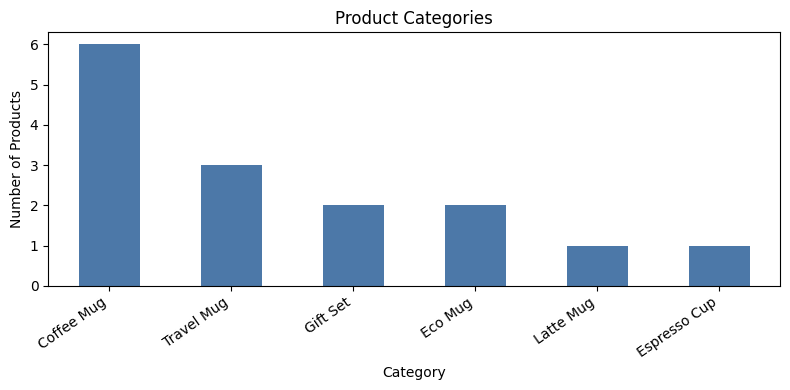

In [8]:
ax = product_category_summary.plot(
    kind="bar",
    x="Category",
    y="Number of products",
    legend=False,
    figsize=(8, 4),
    color="#4C78A8",
)
ax.set_title("Product Categories")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Products")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 5. Order History Summary

In [9]:
order_summary = pd.DataFrame({
    "Metric": ["Orders", "Units ordered", "Total sales value", "Average order value"],
    "Value": [
        len(orders),
        int(orders["quantity"].sum()),
        round(orders["total_price"].sum(), 2),
        round(orders["total_price"].mean(), 2),
    ],
})

order_summary

,Metric,Value
0,Orders,33.00
1,Units ordered,47.00
2,Total sales value,791.53
3,Average order value,23.99


In [10]:
order_status_summary = (
    orders["status"]
    .value_counts()
    .rename_axis("Order status")
    .reset_index(name="Number of orders")
)

order_status_summary

,Order status,Number of orders
0,Shipped,9
1,Delivered,9
2,Processing,6
3,Pending,6
4,Cancelled,3


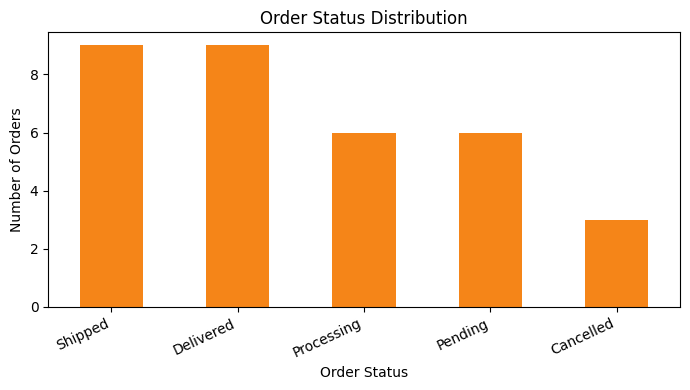

In [11]:
ax = order_status_summary.plot(
    kind="bar",
    x="Order status",
    y="Number of orders",
    legend=False,
    figsize=(7, 4),
    color="#F58518",
)
ax.set_title("Order Status Distribution")
ax.set_xlabel("Order Status")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [12]:
popular_products = (
    orders.groupby("product_name", as_index=False)
    .agg(
        Orders=("order_number", "count"),
        Units_sold=("quantity", "sum"),
        Sales_value=("total_price", "sum"),
    )
    .sort_values(["Units_sold", "Sales_value"], ascending=False)
)

popular_products

,product_name,Orders,Units_sold,Sales_value
0,Classic Blue Mug,7,13,168.87
1,Classic Red Mug,7,12,155.88
2,Classic White Mug,7,9,107.91
3,Gift Mug Set,7,7,244.93
4,Large Travel Mug,5,6,113.94


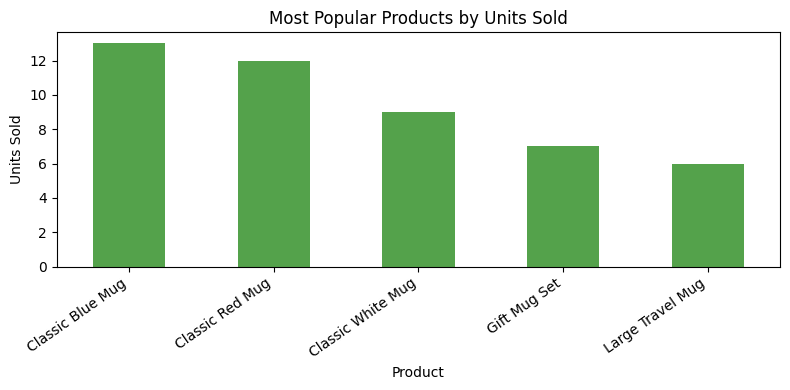

In [13]:
ax = popular_products.plot(
    kind="bar",
    x="product_name",
    y="Units_sold",
    legend=False,
    figsize=(8, 4),
    color="#54A24B",
)
ax.set_title("Most Popular Products by Units Sold")
ax.set_xlabel("Product")
ax.set_ylabel("Units Sold")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 6. Evaluation Survey Results

This table and chart can be used in the report as evidence of user evaluation.

In [14]:
rating_columns = [
    "chatbot_accuracy",
    "rating_recommendations",
    "rating_speed",
    "rating_overall",
]

evaluation_summary = (
    survey[rating_columns]
    .mean()
    .round(2)
    .rename_axis("Metric")
    .reset_index(name="Average rating out of 5")
)

evaluation_summary

,Metric,Average rating out of 5
0,chatbot_accuracy,4.4
1,rating_recommendations,4.0
2,rating_speed,4.6
3,rating_overall,4.4


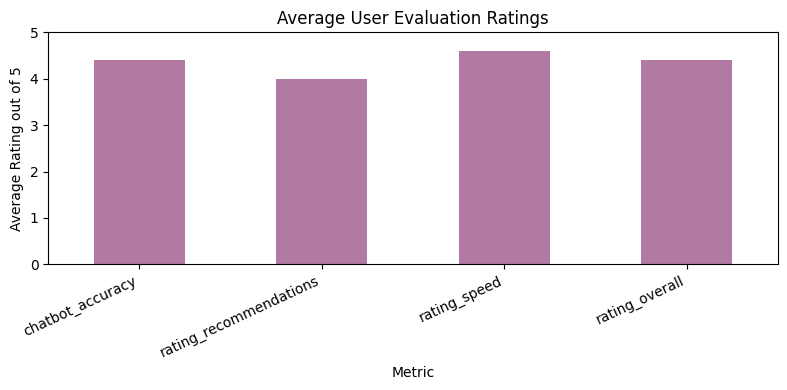

In [15]:
ax = evaluation_summary.plot(
    kind="bar",
    x="Metric",
    y="Average rating out of 5",
    legend=False,
    figsize=(8, 4),
    color="#B279A2",
)
ax.set_title("Average User Evaluation Ratings")
ax.set_xlabel("Metric")
ax.set_ylabel("Average Rating out of 5")
ax.set_ylim(0, 5)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 7. Combined Results Table

This table is useful for the report's **Results and Analysis** section.

In [16]:
combined_results = pd.DataFrame({
    "Metric": [
        "Number of intents",
        "Training queries",
        "Responses",
        "Products",
        "Orders analysed",
        "Total units ordered",
        "Total sales value",
        "Average chatbot accuracy rating",
        "Average recommendation rating",
        "Average speed rating",
        "Average overall rating",
    ],
    "Result": [
        len(intents),
        sum(len(intent.get("queries", [])) for intent in intents),
        sum(len(intent.get("responses", [])) for intent in intents),
        len(products),
        len(orders),
        int(orders["quantity"].sum()),
        round(orders["total_price"].sum(), 2),
        round(survey["chatbot_accuracy"].mean(), 2),
        round(survey["rating_recommendations"].mean(), 2),
        round(survey["rating_speed"].mean(), 2),
        round(survey["rating_overall"].mean(), 2),
    ],
})

combined_results

,Metric,Result
0,Number of intents,38.00
1,Training queries,332.00
2,Responses,126.00
3,Products,15.00
4,Orders analysed,33.00
5,Total units ordered,47.00
6,Total sales value,791.53
7,Average chatbot accuracy rating,4.40
8,Average recommendation rating,4.00
9,Average speed rating,4.60


## 8. Example Chatbot Test Cases

Use this table to show example queries and expected chatbot behaviour in the report.

In [17]:
test_cases = pd.DataFrame([
    {
        "User query": "What products do you sell?",
        "Expected intent": "items",
        "Expected behaviour": "Shows product information",
    },
    {
        "User query": "Track my order",
        "Expected intent": "order_status",
        "Expected behaviour": "Asks for or checks order details",
    },
    {
        "User query": "Recommend a mug for me",
        "Expected intent": "recommendations",
        "Expected behaviour": "Shows recommended products",
    },
    {
        "User query": "Show best selling mugs",
        "Expected intent": "product_popularity_analysis",
        "Expected behaviour": "Shows popular products from order history",
    },
    {
        "User query": "Run market basket analysis",
        "Expected intent": "market_basket_analysis",
        "Expected behaviour": "Shows frequently bought product pairs",
    },
])

test_cases

,User query,Expected intent,Expected behaviour
0,What products do you sell?,items,Shows product information
1,Track my order,order_status,Asks for or checks order details
2,Recommend a mug for me,recommendations,Shows recommended products
3,Show best selling mugs,product_popularity_analysis,Shows popular products from order history
4,Run market basket analysis,market_basket_analysis,Shows frequently bought product pairs
